# Evaluating Machine Learning Models for Multi-Class Hate Speech and Offensive Language Classification Using Natural Language Processing Techniques and Prototype Development

# Importing Libraries and Basic Few Operations

In [1]:
# I imported the NumPy library for performing numerical computations.
import numpy as np

# I imported the Pandas library for data loading and manipulation.
import pandas as pd

# I imported Matplotlib for creating data visualizations.
import matplotlib.pyplot as plt

# I imported Seaborn for generating statistical visualizations.
import seaborn as sns

# I configured Pandas to display all columns in the output.
pd.set_option('display.max_columns', None)

# I configured Pandas to display the complete text content within each column.
pd.set_option('display.max_colwidth', None)

# I loaded the dataset into a Pandas DataFrame.
df = pd.read_csv("labeled_data.csv")

# I displayed a heading for the first five rows.
print("First Five Rows of the Dataset")

# I displayed the first five records of the dataset.
print(df.head())

# I displayed a heading for the dataset shape.
print("\nDataset Shape")

# I displayed the number of rows and columns in the dataset.
print(df.shape)

First Five Rows of the Dataset
   Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0           0      3            0                   0        3      2   
1           1      3            0                   3        0      1   
2           2      3            0                   3        0      1   
3           3      3            0                   2        1      1   
4           4      6            0                   6        0      1   

                                                                                                                                          tweet  
0  !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...  
1                                                         !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!  
2                      !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a 

# Data Inspection 

In [2]:
# I displayed the total number of observations in the dataset.
print("\nNumber of Observations:", df.shape[0])

# I displayed the total number of columns in the dataset.
print("Number of Columns:", df.shape[1])

# I displayed the names of all columns in the dataset.
print("\nColumn Names:")
print(df.columns.tolist())

# I displayed the target variable used for prediction.
print("\nTarget Variable:")
print("class")

# I displayed the data types of all columns.
print("\nData Types:")
print(df.dtypes)

# I displayed the total number of missing values in each column.
print("\nMissing Values:")
print(df.isnull().sum())

# I displayed the total number of duplicate records in the dataset.
print("\nDuplicate Records:")
print(df.duplicated().sum())

# I displayed the unique values present in the target variable.
print("\nUnique Values in Target Variable:")
print(df["class"].unique())


Number of Observations: 24783
Number of Columns: 7

Column Names:
['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']

Target Variable:
class

Data Types:
Unnamed: 0             int64
count                  int64
hate_speech            int64
offensive_language     int64
neither                int64
class                  int64
tweet                 object
dtype: object

Missing Values:
Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

Duplicate Records:
0

Unique Values in Target Variable:
[2 1 0]


# Data Pre-Processing & Involving NLP Processing 

In [3]:
# I imported the required libraries for text preprocessing.
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk

# I downloaded the English stopwords.
nltk.download('stopwords')

# I displayed the total number of missing values before preprocessing.
print("Missing Values Before Preprocessing:")
print(df.isnull().sum())

# I removed the missing values from the dataset.
df = df.dropna()

# I displayed the total number of duplicate records before preprocessing.
print("\nDuplicate Records Before Preprocessing:")
print(df.duplicated().sum())

# I removed the duplicate records from the dataset.
df = df.drop_duplicates()

# I removed the unnecessary 'count' column from the dataset.
df = df.drop(columns=['count'])

# I created a list of English stopwords.
stop_words = set(stopwords.words('english'))

# I initialized the Porter Stemmer.
stemmer = PorterStemmer()

# I defined a function to preprocess the tweet text.
def preprocess_text(text):

    # I converted the text into lowercase.
    text = text.lower()

    # I removed web links from the text.
    text = re.sub(r'http\S+|www\S+', '', text)

    # I removed user mentions from the text.
    text = re.sub(r'@\w+', '', text)

    # I removed the hashtag symbol while keeping the word.
    text = re.sub(r'#', '', text)

    # I removed punctuation marks from the text.
    text = text.translate(str.maketrans('', '', string.punctuation))

    # I removed numerical values from the text.
    text = re.sub(r'\d+', '', text)

    # I removed extra white spaces from the text.
    text = re.sub(r'\s+', ' ', text).strip()

    # I removed stopwords from the text.
    words = [word for word in text.split() if word not in stop_words]

    # I applied stemming to each remaining word.
    words = [stemmer.stem(word) for word in words]

    # I joined the processed words into a single sentence.
    return " ".join(words)

# I applied the preprocessing function to the tweet text column.
df["tweet"] = df["tweet"].apply(preprocess_text)

# I displayed the first five rows after preprocessing.
print("\nFirst Five Rows After Preprocessing:")
print(df.head())

# I displayed the dataset shape after preprocessing.
print("\nDataset Shape After Preprocessing:")
print(df.shape)

# I displayed the remaining missing values after preprocessing.
print("\nMissing Values After Preprocessing:")
print(df.isnull().sum())

# I displayed the remaining duplicate records after preprocessing.
print("\nDuplicate Records After Preprocessing:")
print(df.duplicated().sum())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tiruv\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Missing Values Before Preprocessing:
Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

Duplicate Records Before Preprocessing:
0

First Five Rows After Preprocessing:
   Unnamed: 0  hate_speech  offensive_language  neither  class  \
0           0            0                   0        3      2   
1           1            0                   3        0      1   
2           2            0                   3        0      1   
3           3            0                   2        1      1   
4           4            0                   6        0      1   

                                                            tweet  
0  rt woman shouldnt complain clean hous amp man alway take trash  
1             rt boy dat coldtyga dwn bad cuffin dat hoe st place  
2                rt dawg rt ever fuck bitch start cri confus shit  
3                               

# Exploratory Data Analysis 

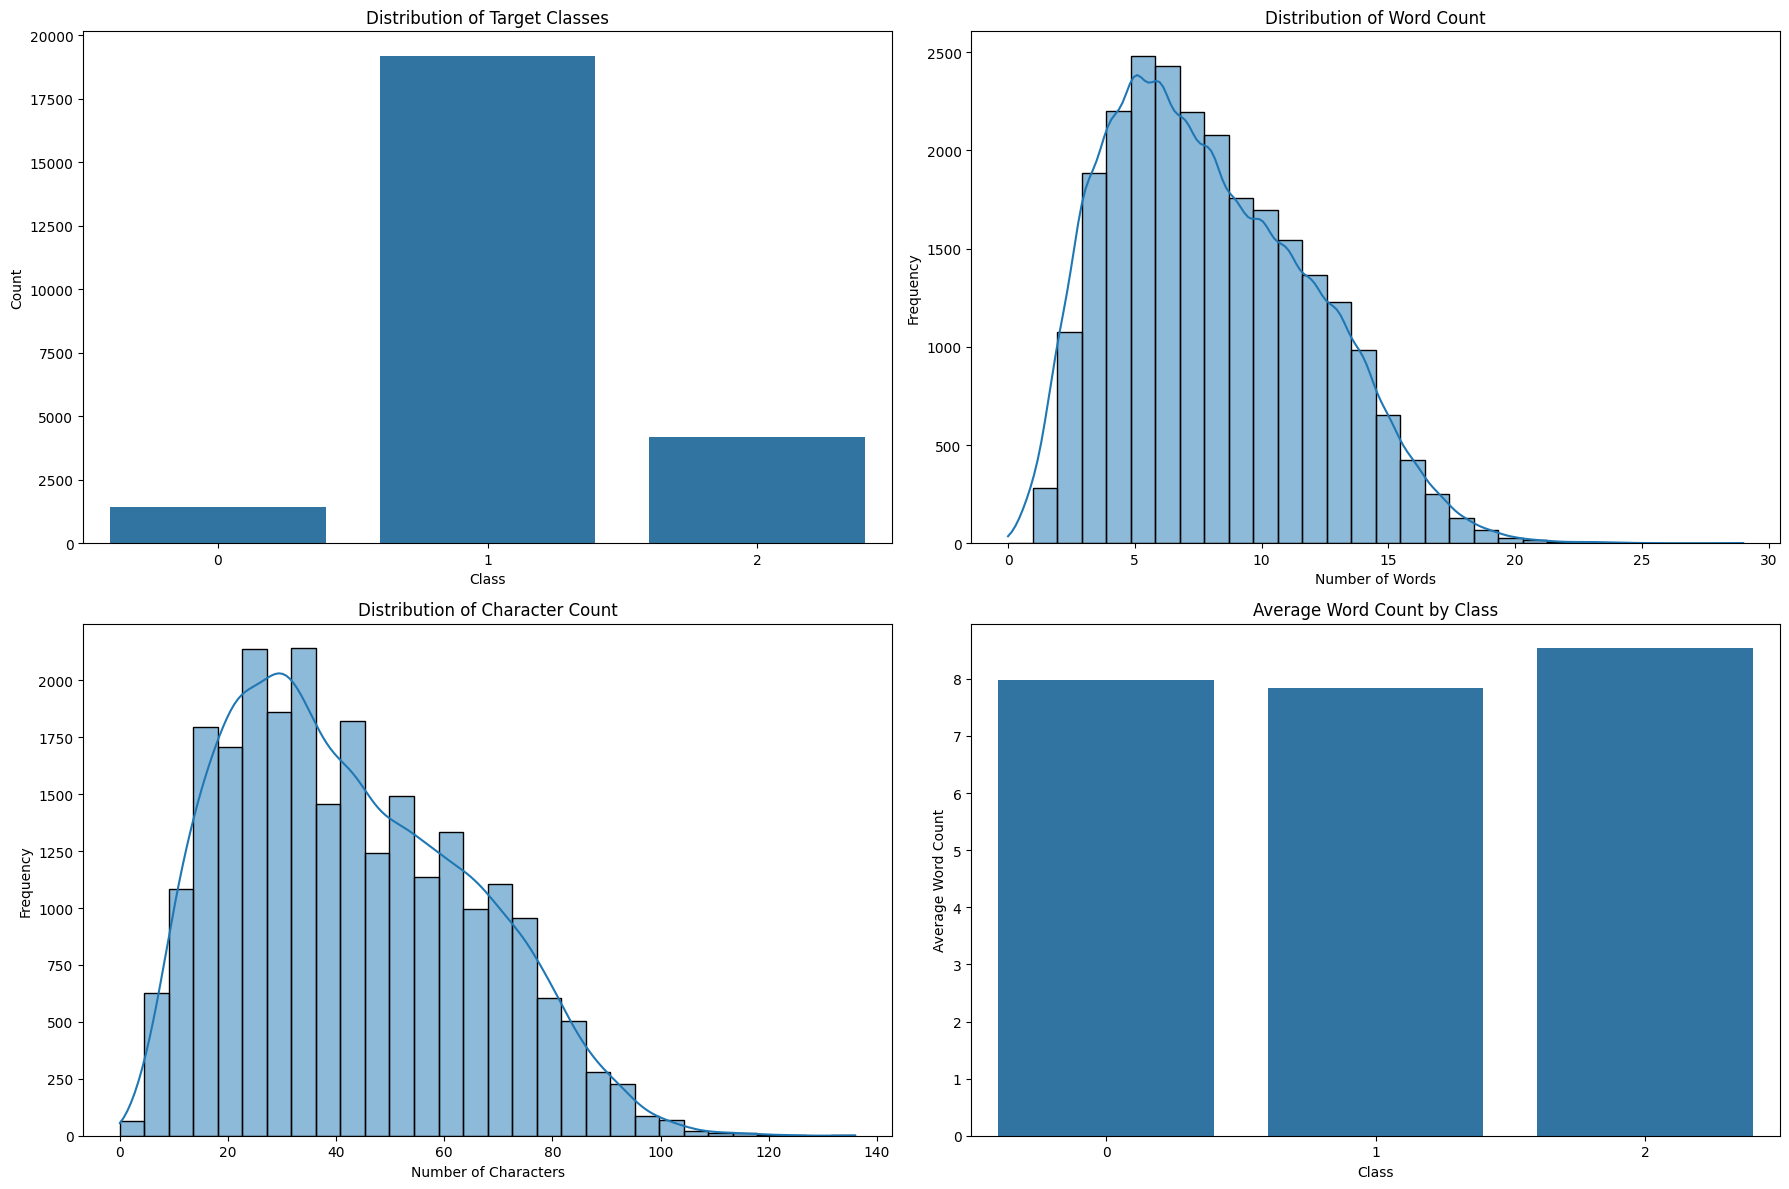

In [4]:
# I created a figure to display all exploratory data analysis plots.
plt.figure(figsize=(18,12))

# I created the plot to display the distribution of the target classes.
plt.subplot(2,2,1)
sns.countplot(data=df, x='class')
plt.title("Distribution of Target Classes")
plt.xlabel("Class")
plt.ylabel("Count")

# I calculated the number of words in each tweet.
df['Word_Count'] = df['tweet'].apply(lambda x: len(str(x).split()))

# I created the  plot to display the distribution of word counts.
plt.subplot(2,2,2)
sns.histplot(df['Word_Count'], bins=30, kde=True)
plt.title("Distribution of Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

# I calculated the number of characters in each tweet.
df['Character_Count'] = df['tweet'].apply(len)

# I created the plot to display the distribution of character counts.
plt.subplot(2,2,3)
sns.histplot(df['Character_Count'], bins=30, kde=True)
plt.title("Distribution of Character Count")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

# I calculated the average word count for each target class.
avg_words = df.groupby('class')['Word_Count'].mean().reset_index()

# I created the plot to compare the average word count across classes.
plt.subplot(2,2,4)
sns.barplot(data=avg_words, x='class', y='Word_Count')
plt.title("Average Word Count by Class")
plt.xlabel("Class")
plt.ylabel("Average Word Count")

# I adjusted the spacing between the plots.
plt.tight_layout()

# I displayed all the plots.
plt.show()

# Feature Extraction Using TF-IDF & BOW Techniques , Splitting the Dataset & Handling Class Imbalance Using SMOTE (Synthetic Minority Oversampling Technique)

Bag of Words Feature Matrix
Training Feature Matrix Shape: (19826, 5000)
Testing Feature Matrix Shape: (4957, 5000)
Total Number of Features: 5000

First 20 Bag of Words Features:
['aa' 'aap' 'aaron' 'ab' 'abil' 'abl' 'abo' 'abort' 'absolut' 'abt' 'abu'
 'abus' 'ac' 'accent' 'accept' 'accid' 'accident' 'accord' 'account'
 'accur']

TF-IDF Feature Matrix
Training Feature Matrix Shape: (19826, 5000)
Testing Feature Matrix Shape: (4957, 5000)
Total Number of Features: 5000

First 20 TF-IDF Features:
['aa' 'aap' 'aaron' 'ab' 'abil' 'abl' 'abo' 'abort' 'absolut' 'abt' 'abu'
 'abus' 'ac' 'accent' 'accept' 'accid' 'accident' 'accord' 'account'
 'accur']

Training Class Distribution:
class
1    15352
2     3330
0     1144
Name: count, dtype: int64

Testing Class Distribution:
class
1    3838
2     833
0     286
Name: count, dtype: int64

Bag of Words After SMOTE
Training Feature Shape Before SMOTE: (19826, 5000)
Training Target Shape Before SMOTE: (19826,)
Training Feature Shape After SMOTE: (

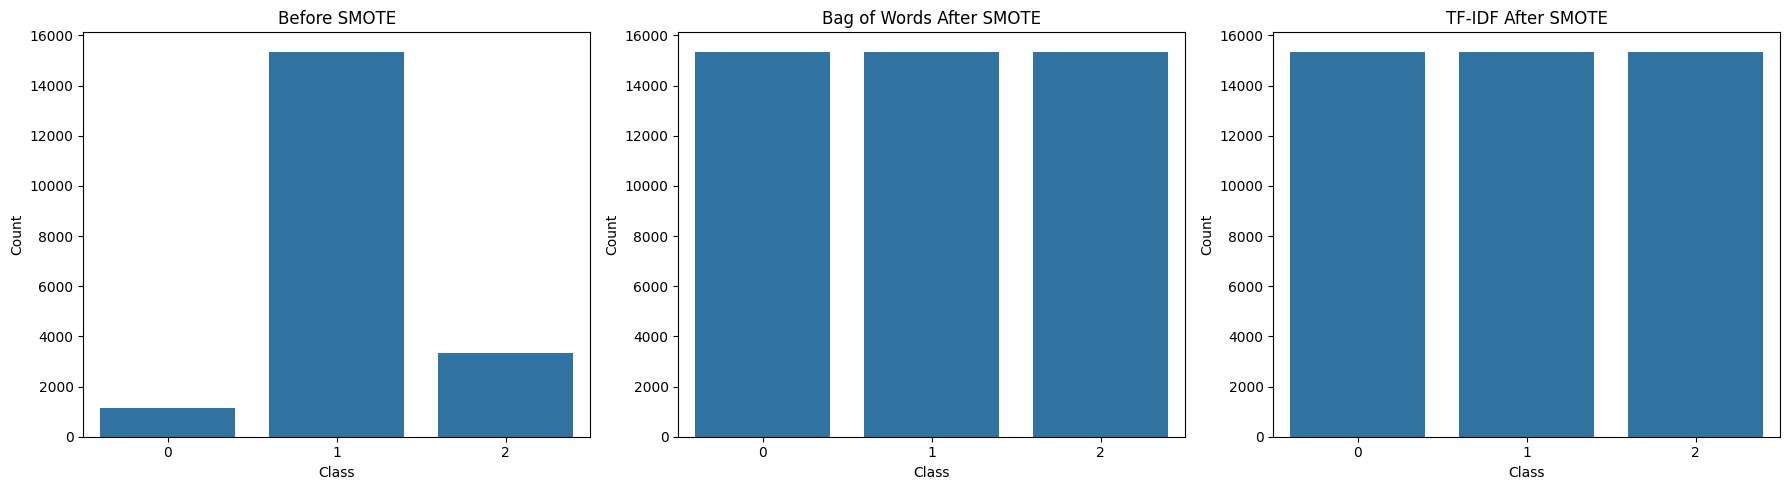

In [5]:
# I imported the required libraries.
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# I selected the tweet column as the input feature.
X = df["tweet"]

# I selected the class column as the target variable.
y = df["class"]

# I split the dataset into training and testing sets.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# I initialized the Bag of Words vectorizer.
bow = CountVectorizer(max_features=5000)

# I fitted the Bag of Words vectorizer on the training data.
X_train_bow = bow.fit_transform(X_train_text)

# I transformed the testing data using the fitted Bag of Words vectorizer.
X_test_bow = bow.transform(X_test_text)

# I initialized the TF-IDF vectorizer.
tfidf = TfidfVectorizer(max_features=5000)

# I fitted the TF-IDF vectorizer on the training data.
X_train_tfidf = tfidf.fit_transform(X_train_text)

# I transformed the testing data using the fitted TF-IDF vectorizer.
X_test_tfidf = tfidf.transform(X_test_text)

# I displayed the Bag of Words feature matrix information.
print("Bag of Words Feature Matrix")
print("Training Feature Matrix Shape:", X_train_bow.shape)
print("Testing Feature Matrix Shape:", X_test_bow.shape)
print("Total Number of Features:", len(bow.get_feature_names_out()))

print("\nFirst 20 Bag of Words Features:")
print(bow.get_feature_names_out()[:20])

# I displayed the TF-IDF feature matrix information.
print("\nTF-IDF Feature Matrix")
print("Training Feature Matrix Shape:", X_train_tfidf.shape)
print("Testing Feature Matrix Shape:", X_test_tfidf.shape)
print("Total Number of Features:", len(tfidf.get_feature_names_out()))

print("\nFirst 20 TF-IDF Features:")
print(tfidf.get_feature_names_out()[:20])

# I displayed the class distributions.
print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

# I initialized the SMOTE technique.
smote = SMOTE(random_state=42)

# I applied SMOTE to the Bag of Words training data.
X_train_bow_smote, y_train_bow_smote = smote.fit_resample(
    X_train_bow,
    y_train
)

# I applied SMOTE to the TF-IDF training data.
X_train_tfidf_smote, y_train_tfidf_smote = smote.fit_resample(
    X_train_tfidf,
    y_train
)

# I displayed the Bag of Words dataset after applying SMOTE.
print("\nBag of Words After SMOTE")
print("Training Feature Shape Before SMOTE:", X_train_bow.shape)
print("Training Target Shape Before SMOTE:", y_train.shape)
print("Training Feature Shape After SMOTE:", X_train_bow_smote.shape)
print("Training Target Shape After SMOTE:", y_train_bow_smote.shape)

print("\nClass Distribution After SMOTE (Bag of Words):")
print(y_train_bow_smote.value_counts())

# I displayed the TF-IDF dataset after applying SMOTE.
print("\nTF-IDF After SMOTE")
print("Training Feature Shape Before SMOTE:", X_train_tfidf.shape)
print("Training Target Shape Before SMOTE:", y_train.shape)
print("Training Feature Shape After SMOTE:", X_train_tfidf_smote.shape)
print("Training Target Shape After SMOTE:", y_train_tfidf_smote.shape)

print("\nClass Distribution After SMOTE (TF-IDF):")
print(y_train_tfidf_smote.value_counts())

# I created a figure to compare the class distributions.
plt.figure(figsize=(18,5))

# I plotted the class distribution before applying SMOTE.
plt.subplot(1,3,1)
sns.countplot(x=y_train)
plt.title("Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

# I plotted the class distribution after applying SMOTE to the Bag of Words dataset.
plt.subplot(1,3,2)
sns.countplot(x=y_train_bow_smote)
plt.title("Bag of Words After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

# I plotted the class distribution after applying SMOTE to the TF-IDF dataset.
plt.subplot(1,3,3)
sns.countplot(x=y_train_tfidf_smote)
plt.title("TF-IDF After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

# I adjusted the spacing between the plots.
plt.tight_layout()

# I displayed the plots.
plt.show()

# Training & Evaluating the Models 

# Technique 1 : Term Frequency - Inverse Document Frequency (TF-IDF)

# Logistic Regression (TF-IDF)

In [6]:
# I imported the required libraries.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Logistic Regression model.
lr_tfidf = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# I trained the Logistic Regression model.
lr_tfidf.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I predicted the testing labels.
y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

# I predicted the class probabilities.
y_prob_tfidf = lr_tfidf.predict_proba(X_test_tfidf)

# I calculated the evaluation metrics.
lr_tfidf_accuracy = accuracy_score(
    y_test,
    y_pred_tfidf
)

lr_tfidf_precision = precision_score(
    y_test,
    y_pred_tfidf,
    average="weighted"
)

lr_tfidf_recall = recall_score(
    y_test,
    y_pred_tfidf,
    average="weighted"
)

lr_tfidf_f1_score = f1_score(
    y_test,
    y_pred_tfidf,
    average="weighted"
)

lr_tfidf_auc = roc_auc_score(
    y_test,
    y_prob_tfidf,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nLogistic Regression Performance")

print(f"Accuracy      : {lr_tfidf_accuracy:.4f}")
print(f"Precision     : {lr_tfidf_precision:.4f}")
print(f"Recall        : {lr_tfidf_recall:.4f}")
print(f"F1-Score      : {lr_tfidf_f1_score:.4f}")
print(f"ROC-AUC Score : {lr_tfidf_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")

print(classification_report(y_test, y_pred_tfidf))


Logistic Regression Performance
Accuracy      : 0.8477
Precision     : 0.8918
Recall        : 0.8477
F1-Score      : 0.8637
ROC-AUC Score : 0.9301

Classification Report
              precision    recall  f1-score   support

           0       0.29      0.58      0.38       286
           1       0.96      0.85      0.90      3838
           2       0.79      0.92      0.85       833

    accuracy                           0.85      4957
   macro avg       0.68      0.78      0.71      4957
weighted avg       0.89      0.85      0.86      4957



# Technique 2 : Bag Of Words (BoW)

# Logistic Regression (BoW) 

In [7]:
# I imported the required libraries.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Logistic Regression model.
lr_bow = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# I trained the Logistic Regression model.
lr_bow.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I predicted the testing labels.
y_pred_bow = lr_bow.predict(X_test_bow)

# I predicted the class probabilities.
y_prob_bow = lr_bow.predict_proba(X_test_bow)

# I calculated the evaluation metrics.
lr_bow_accuracy = accuracy_score(
    y_test,
    y_pred_bow
)

lr_bow_precision = precision_score(
    y_test,
    y_pred_bow,
    average="weighted"
)

lr_bow_recall = recall_score(
    y_test,
    y_pred_bow,
    average="weighted"
)

lr_bow_f1_score = f1_score(
    y_test,
    y_pred_bow,
    average="weighted"
)

lr_bow_auc = roc_auc_score(
    y_test,
    y_prob_bow,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nLogistic Regression Performance (Bag of Words)")
print(f"Accuracy      : {lr_bow_accuracy:.4f}")
print(f"Precision     : {lr_bow_precision:.4f}")
print(f"Recall        : {lr_bow_recall:.4f}")
print(f"F1-Score      : {lr_bow_f1_score:.4f}")
print(f"ROC-AUC Score : {lr_bow_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_bow))


Logistic Regression Performance (Bag of Words)
Accuracy      : 0.8521
Precision     : 0.8787
Recall        : 0.8521
F1-Score      : 0.8635
ROC-AUC Score : 0.8989

Classification Report
              precision    recall  f1-score   support

           0       0.26      0.43      0.32       286
           1       0.93      0.88      0.91      3838
           2       0.83      0.87      0.85       833

    accuracy                           0.85      4957
   macro avg       0.68      0.73      0.69      4957
weighted avg       0.88      0.85      0.86      4957



# LightGBM (TF-IDF)

In [10]:
# I imported the required libraries.
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the LightGBM model.
lightgbm_tfidf = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

# I trained the LightGBM model.
lightgbm_tfidf.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I predicted the testing labels.
y_pred_lightgbm_tfidf = lightgbm_tfidf.predict(X_test_tfidf)

# I predicted the class probabilities.
y_prob_lightgbm_tfidf = lightgbm_tfidf.predict_proba(X_test_tfidf)

# I calculated the evaluation metrics.
lightgbm_tfidf_accuracy = accuracy_score(
    y_test,
    y_pred_lightgbm_tfidf
)

lightgbm_tfidf_precision = precision_score(
    y_test,
    y_pred_lightgbm_tfidf,
    average="weighted"
)

lightgbm_tfidf_recall = recall_score(
    y_test,
    y_pred_lightgbm_tfidf,
    average="weighted"
)

lightgbm_tfidf_f1_score = f1_score(
    y_test,
    y_pred_lightgbm_tfidf,
    average="weighted"
)

lightgbm_tfidf_auc = roc_auc_score(
    y_test,
    y_prob_lightgbm_tfidf,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nLightGBM Performance")

print(f"Accuracy      : {lightgbm_tfidf_accuracy:.4f}")
print(f"Precision     : {lightgbm_tfidf_precision:.4f}")
print(f"Recall        : {lightgbm_tfidf_recall:.4f}")
print(f"F1-Score      : {lightgbm_tfidf_f1_score:.4f}")
print(f"ROC-AUC Score : {lightgbm_tfidf_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_lightgbm_tfidf))


LightGBM Performance
Accuracy      : 0.8838
Precision     : 0.9024
Recall        : 0.8838
F1-Score      : 0.8907
ROC-AUC Score : 0.9477

Classification Report
              precision    recall  f1-score   support

           0       0.37      0.53      0.44       286
           1       0.96      0.90      0.93      3838
           2       0.82      0.94      0.87       833

    accuracy                           0.88      4957
   macro avg       0.72      0.79      0.75      4957
weighted avg       0.90      0.88      0.89      4957



# LightGBM (BoW)

In [11]:
# I imported the required libraries.
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I converted the feature matrices to float32.
X_train_bow_smote = X_train_bow_smote.astype("float32")
X_test_bow = X_test_bow.astype("float32")

# I initialized the LightGBM model.
lightgbm_bow = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

# I trained the LightGBM model.
lightgbm_bow.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I predicted the testing labels.
y_pred_lightgbm_bow = lightgbm_bow.predict(
    X_test_bow
)

# I predicted the class probabilities.
y_prob_lightgbm_bow = lightgbm_bow.predict_proba(
    X_test_bow
)

# I calculated the evaluation metrics.
lightgbm_bow_accuracy = accuracy_score(
    y_test,
    y_pred_lightgbm_bow
)

lightgbm_bow_precision = precision_score(
    y_test,
    y_pred_lightgbm_bow,
    average="weighted"
)

lightgbm_bow_recall = recall_score(
    y_test,
    y_pred_lightgbm_bow,
    average="weighted"
)

lightgbm_bow_f1_score = f1_score(
    y_test,
    y_pred_lightgbm_bow,
    average="weighted"
)

lightgbm_bow_auc = roc_auc_score(
    y_test,
    y_prob_lightgbm_bow,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nLightGBM Performance (Bag of Words)")

print(f"Accuracy      : {lightgbm_bow_accuracy:.4f}")
print(f"Precision     : {lightgbm_bow_precision:.4f}")
print(f"Recall        : {lightgbm_bow_recall:.4f}")
print(f"F1-Score      : {lightgbm_bow_f1_score:.4f}")
print(f"ROC-AUC Score : {lightgbm_bow_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_lightgbm_bow))


LightGBM Performance (Bag of Words)
Accuracy      : 0.8759
Precision     : 0.8880
Recall        : 0.8759
F1-Score      : 0.8810
ROC-AUC Score : 0.9170

Classification Report
              precision    recall  f1-score   support

           0       0.33      0.42      0.37       286
           1       0.94      0.90      0.92      3838
           2       0.82      0.91      0.86       833

    accuracy                           0.88      4957
   macro avg       0.70      0.74      0.72      4957
weighted avg       0.89      0.88      0.88      4957



# Decision Tree(TF-IDF)

In [8]:
# I imported the required libraries.
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Decision Tree model.
decision_tree_tfidf = DecisionTreeClassifier(
    random_state=42
)

# I trained the Decision Tree model.
decision_tree_tfidf.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I predicted the testing labels.
y_pred_decision_tree_tfidf = decision_tree_tfidf.predict(
    X_test_tfidf
)

# I predicted the class probabilities.
y_prob_decision_tree_tfidf = decision_tree_tfidf.predict_proba(
    X_test_tfidf
)

# I calculated the evaluation metrics.
decision_tree_tfidf_accuracy = accuracy_score(
    y_test,
    y_pred_decision_tree_tfidf
)

decision_tree_tfidf_precision = precision_score(
    y_test,
    y_pred_decision_tree_tfidf,
    average="weighted"
)

decision_tree_tfidf_recall = recall_score(
    y_test,
    y_pred_decision_tree_tfidf,
    average="weighted"
)

decision_tree_tfidf_f1_score = f1_score(
    y_test,
    y_pred_decision_tree_tfidf,
    average="weighted"
)

decision_tree_tfidf_auc = roc_auc_score(
    y_test,
    y_prob_decision_tree_tfidf,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nDecision Tree Performance (TF-IDF)")

print(f"Accuracy      : {decision_tree_tfidf_accuracy:.4f}")
print(f"Precision     : {decision_tree_tfidf_precision:.4f}")
print(f"Recall        : {decision_tree_tfidf_recall:.4f}")
print(f"F1-Score      : {decision_tree_tfidf_f1_score:.4f}")
print(f"ROC-AUC Score : {decision_tree_tfidf_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_decision_tree_tfidf))


Decision Tree Performance (TF-IDF)
Accuracy      : 0.8683
Precision     : 0.8850
Recall        : 0.8683
F1-Score      : 0.8755
ROC-AUC Score : 0.8521

Classification Report
              precision    recall  f1-score   support

           0       0.32      0.47      0.38       286
           1       0.94      0.90      0.92      3838
           2       0.83      0.85      0.84       833

    accuracy                           0.87      4957
   macro avg       0.70      0.74      0.71      4957
weighted avg       0.88      0.87      0.88      4957



# Decision Tree (BoW)

In [9]:
# I imported the required libraries.
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Decision Tree model.
decision_tree_bow = DecisionTreeClassifier(
    random_state=42
)

# I trained the Decision Tree model.
decision_tree_bow.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I predicted the testing labels.
y_pred_decision_tree_bow = decision_tree_bow.predict(
    X_test_bow
)

# I predicted the class probabilities.
y_prob_decision_tree_bow = decision_tree_bow.predict_proba(
    X_test_bow
)

# I calculated the evaluation metrics.
decision_tree_bow_accuracy = accuracy_score(
    y_test,
    y_pred_decision_tree_bow
)

decision_tree_bow_precision = precision_score(
    y_test,
    y_pred_decision_tree_bow,
    average="weighted"
)

decision_tree_bow_recall = recall_score(
    y_test,
    y_pred_decision_tree_bow,
    average="weighted"
)

decision_tree_bow_f1_score = f1_score(
    y_test,
    y_pred_decision_tree_bow,
    average="weighted"
)

decision_tree_bow_auc = roc_auc_score(
    y_test,
    y_prob_decision_tree_bow,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nDecision Tree Performance (Bag of Words)")

print(f"Accuracy      : {decision_tree_bow_accuracy:.4f}")
print(f"Precision     : {decision_tree_bow_precision:.4f}")
print(f"Recall        : {decision_tree_bow_recall:.4f}")
print(f"F1-Score      : {decision_tree_bow_f1_score:.4f}")
print(f"ROC-AUC Score : {decision_tree_bow_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_decision_tree_bow))


Decision Tree Performance (Bag of Words)
Accuracy      : 0.7527
Precision     : 0.8669
Recall        : 0.7527
F1-Score      : 0.7974
ROC-AUC Score : 0.8381

Classification Report
              precision    recall  f1-score   support

           0       0.14      0.48      0.21       286
           1       0.93      0.76      0.84      3838
           2       0.80      0.81      0.81       833

    accuracy                           0.75      4957
   macro avg       0.63      0.68      0.62      4957
weighted avg       0.87      0.75      0.80      4957



# Multinominal Naive Bayes (TF-IDF)

In [12]:
# I imported the required libraries.
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Multinomial Naïve Bayes model.
naive_bayes_tfidf = MultinomialNB()

# I trained the Multinomial Naïve Bayes model.
naive_bayes_tfidf.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I predicted the testing labels.
y_pred_naive_bayes_tfidf = naive_bayes_tfidf.predict(
    X_test_tfidf
)

# I predicted the class probabilities.
y_prob_naive_bayes_tfidf = naive_bayes_tfidf.predict_proba(
    X_test_tfidf
)

# I calculated the evaluation metrics.
naive_bayes_tfidf_accuracy = accuracy_score(
    y_test,
    y_pred_naive_bayes_tfidf
)

naive_bayes_tfidf_precision = precision_score(
    y_test,
    y_pred_naive_bayes_tfidf,
    average="weighted"
)

naive_bayes_tfidf_recall = recall_score(
    y_test,
    y_pred_naive_bayes_tfidf,
    average="weighted"
)

naive_bayes_tfidf_f1_score = f1_score(
    y_test,
    y_pred_naive_bayes_tfidf,
    average="weighted"
)

naive_bayes_tfidf_auc = roc_auc_score(
    y_test,
    y_prob_naive_bayes_tfidf,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nMultinomial Naïve Bayes Performance (TF-IDF)")

print(f"Accuracy      : {naive_bayes_tfidf_accuracy:.4f}")
print(f"Precision     : {naive_bayes_tfidf_precision:.4f}")
print(f"Recall        : {naive_bayes_tfidf_recall:.4f}")
print(f"F1-Score      : {naive_bayes_tfidf_f1_score:.4f}")
print(f"ROC-AUC Score : {naive_bayes_tfidf_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_naive_bayes_tfidf))


Multinomial Naïve Bayes Performance (TF-IDF)
Accuracy      : 0.8104
Precision     : 0.8647
Recall        : 0.8104
F1-Score      : 0.8315
ROC-AUC Score : 0.8992

Classification Report
              precision    recall  f1-score   support

           0       0.24      0.55      0.33       286
           1       0.94      0.83      0.88      3838
           2       0.75      0.80      0.78       833

    accuracy                           0.81      4957
   macro avg       0.64      0.73      0.66      4957
weighted avg       0.86      0.81      0.83      4957



# Multinominal Naive Bayes (BoW)

In [13]:
# I imported the required libraries.
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Multinomial Naïve Bayes model.
naive_bayes_bow = MultinomialNB()

# I trained the Multinomial Naïve Bayes model.
naive_bayes_bow.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I predicted the testing labels.
y_pred_naive_bayes_bow = naive_bayes_bow.predict(
    X_test_bow
)

# I predicted the class probabilities.
y_prob_naive_bayes_bow = naive_bayes_bow.predict_proba(
    X_test_bow
)

# I calculated the evaluation metrics.
naive_bayes_bow_accuracy = accuracy_score(
    y_test,
    y_pred_naive_bayes_bow
)

naive_bayes_bow_precision = precision_score(
    y_test,
    y_pred_naive_bayes_bow,
    average="weighted"
)

naive_bayes_bow_recall = recall_score(
    y_test,
    y_pred_naive_bayes_bow,
    average="weighted"
)

naive_bayes_bow_f1_score = f1_score(
    y_test,
    y_pred_naive_bayes_bow,
    average="weighted"
)

naive_bayes_bow_auc = roc_auc_score(
    y_test,
    y_prob_naive_bayes_bow,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nMultinomial Naïve Bayes Performance (Bag of Words)")

print(f"Accuracy      : {naive_bayes_bow_accuracy:.4f}")
print(f"Precision     : {naive_bayes_bow_precision:.4f}")
print(f"Recall        : {naive_bayes_bow_recall:.4f}")
print(f"F1-Score      : {naive_bayes_bow_f1_score:.4f}")
print(f"ROC-AUC Score : {naive_bayes_bow_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_naive_bayes_bow))


Multinomial Naïve Bayes Performance (Bag of Words)
Accuracy      : 0.8566
Precision     : 0.8778
Recall        : 0.8566
F1-Score      : 0.8657
ROC-AUC Score : 0.8993

Classification Report
              precision    recall  f1-score   support

           0       0.30      0.48      0.37       286
           1       0.93      0.89      0.91      3838
           2       0.83      0.83      0.83       833

    accuracy                           0.86      4957
   macro avg       0.69      0.73      0.70      4957
weighted avg       0.88      0.86      0.87      4957



# Combined Comparative Table and Bar Graph for all Default Models 


Bag of Words Model Comparison


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.852128,0.878720,0.852128,0.863494,0.898932
1,LightGBM,0.875933,0.888010,0.875933,0.880972,0.916955
2,Decision Tree,0.752673,0.866907,0.752673,0.797415,0.838145
3,Naïve Bayes,0.856566,0.877771,0.856566,0.865655,0.899253


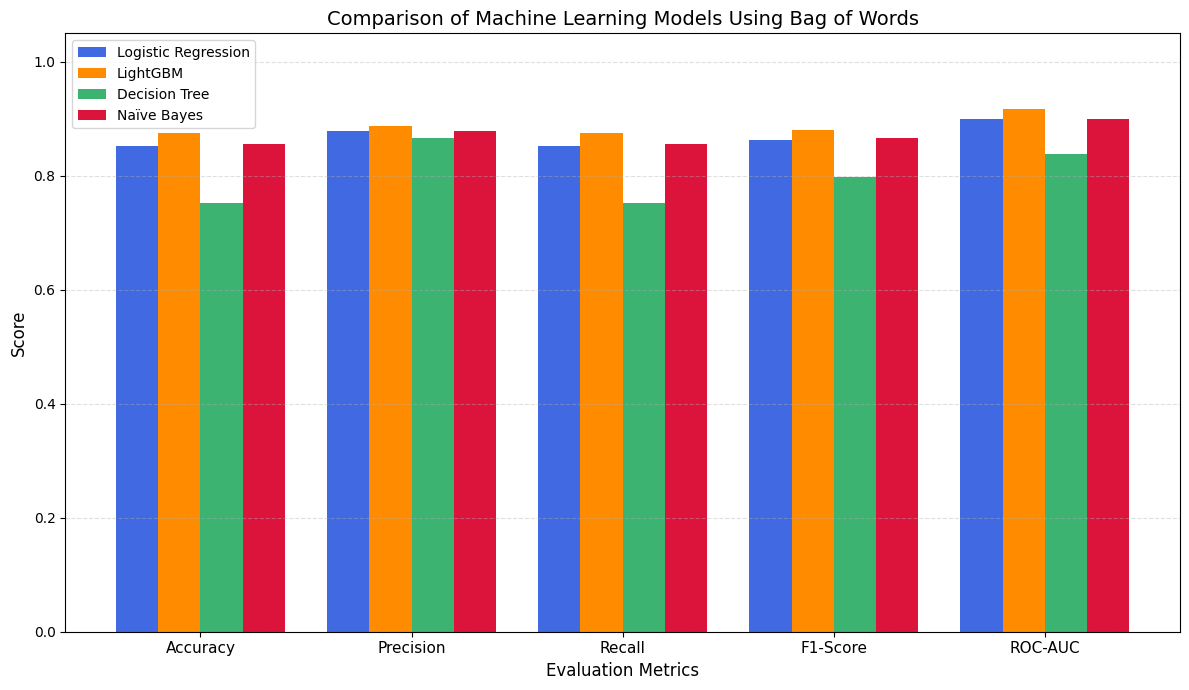

In [14]:
# I imported the required libraries.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# I created the comparison table.
comparison_results_bow = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LightGBM",
        "Decision Tree",
        "Naïve Bayes"
    ],
    "Accuracy": [
        lr_bow_accuracy,
        lightgbm_bow_accuracy,
        decision_tree_bow_accuracy,
        naive_bayes_bow_accuracy
    ],
    "Precision": [
        lr_bow_precision,
        lightgbm_bow_precision,
        decision_tree_bow_precision,
        naive_bayes_bow_precision
    ],
    "Recall": [
        lr_bow_recall,
        lightgbm_bow_recall,
        decision_tree_bow_recall,
        naive_bayes_bow_recall
    ],
    "F1-Score": [
        lr_bow_f1_score,
        lightgbm_bow_f1_score,
        decision_tree_bow_f1_score,
        naive_bayes_bow_f1_score
    ],
    "ROC-AUC": [
        lr_bow_auc,
        lightgbm_bow_auc,
        decision_tree_bow_auc,
        naive_bayes_bow_auc
    ]
})

# I displayed the comparison table.
print("\nBag of Words Model Comparison")
display(comparison_results_bow)

# I created a grouped bar chart.
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(12,7))

plt.bar(
    x - 1.5*width,
    comparison_results_bow.loc[0, metrics],
    width,
    label="Logistic Regression",
    color="royalblue"
)

plt.bar(
    x - 0.5*width,
    comparison_results_bow.loc[1, metrics],
    width,
    label="LightGBM",
    color="darkorange"
)

plt.bar(
    x + 0.5*width,
    comparison_results_bow.loc[2, metrics],
    width,
    label="Decision Tree",
    color="mediumseagreen"
)

plt.bar(
    x + 1.5*width,
    comparison_results_bow.loc[3, metrics],
    width,
    label="Naïve Bayes",
    color="crimson"
)

plt.xticks(x, metrics, fontsize=11)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Evaluation Metrics", fontsize=12)
plt.title("Comparison of Machine Learning Models Using Bag of Words", fontsize=14)

plt.ylim(0, 1.05)

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# Visual Analysis for each metric : Default Models 

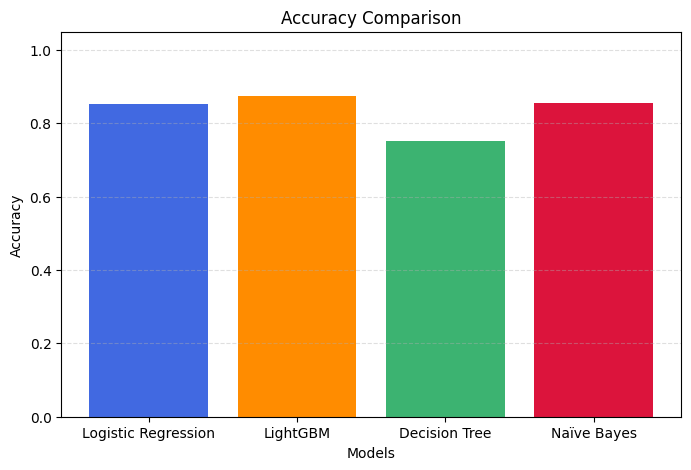

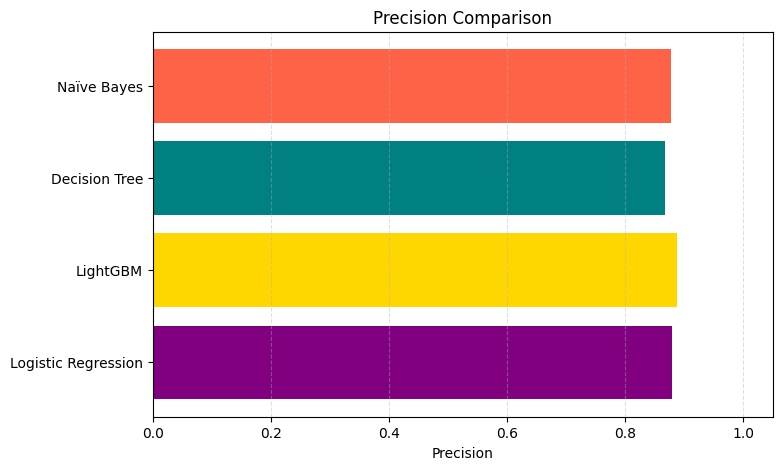

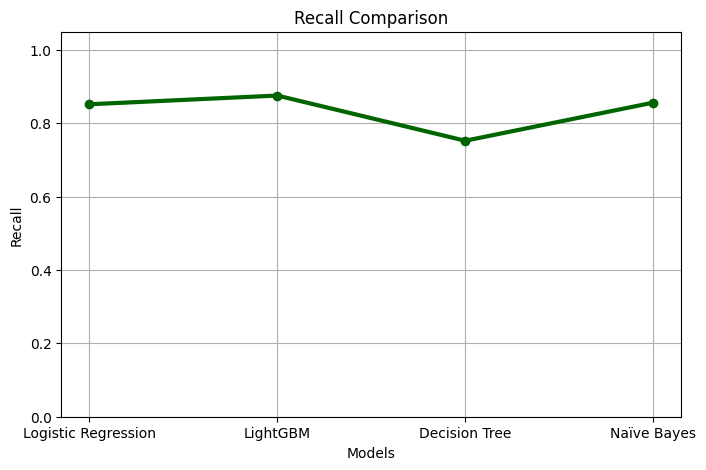

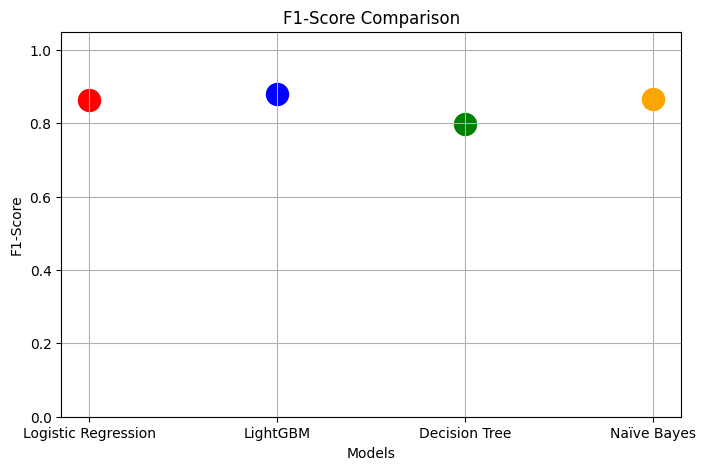

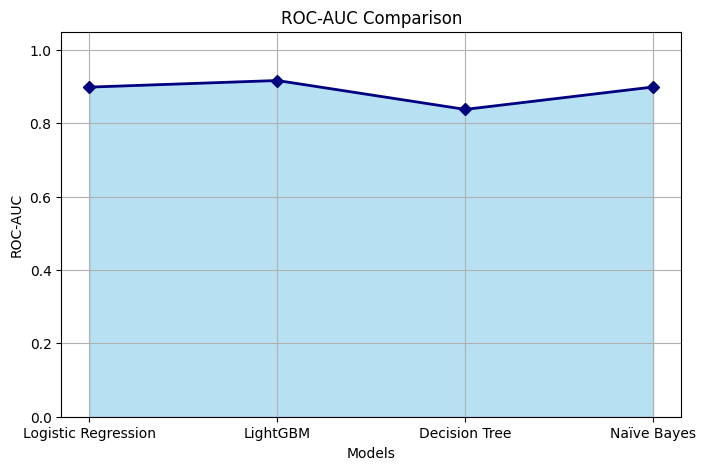

In [15]:
# I imported the required libraries.
import matplotlib.pyplot as plt

models = comparison_results_bow["Model"]

# Accuracy - Bar Chart
plt.figure(figsize=(8,5))
plt.bar(
    models,
    comparison_results_bow["Accuracy"],
    color=["royalblue", "darkorange", "mediumseagreen", "crimson"]
)
plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0,1.05)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


# Precision - Horizontal Bar Chart
plt.figure(figsize=(8,5))
plt.barh(
    models,
    comparison_results_bow["Precision"],
    color=["purple", "gold", "teal", "tomato"]
)
plt.title("Precision Comparison")
plt.xlabel("Precision")
plt.xlim(0,1.05)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.show()


# Recall - Line Chart
plt.figure(figsize=(8,5))
plt.plot(
    models,
    comparison_results_bow["Recall"],
    marker="o",
    linewidth=3,
    color="darkgreen"
)
plt.title("Recall Comparison")
plt.xlabel("Models")
plt.ylabel("Recall")
plt.ylim(0,1.05)
plt.grid(True)
plt.show()


# F1-Score - Scatter Plot
plt.figure(figsize=(8,5))

colors = ["red", "blue", "green", "orange"]

for i, model in enumerate(models):
    plt.scatter(
        model,
        comparison_results_bow["F1-Score"][i],
        s=250,
        color=colors[i]
    )

plt.title("F1-Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1-Score")
plt.ylim(0,1.05)
plt.grid(True)
plt.show()


# ROC-AUC - Area Chart
plt.figure(figsize=(8,5))
plt.fill_between(
    models,
    comparison_results_bow["ROC-AUC"],
    color="skyblue",
    alpha=0.6
)
plt.plot(
    models,
    comparison_results_bow["ROC-AUC"],
    marker="D",
    linewidth=2,
    color="navy"
)
plt.title("ROC-AUC Comparison")
plt.xlabel("Models")
plt.ylabel("ROC-AUC")
plt.ylim(0,1.05)
plt.grid(True)
plt.show()

# Combined AUC-ROC Curve for Default Models 

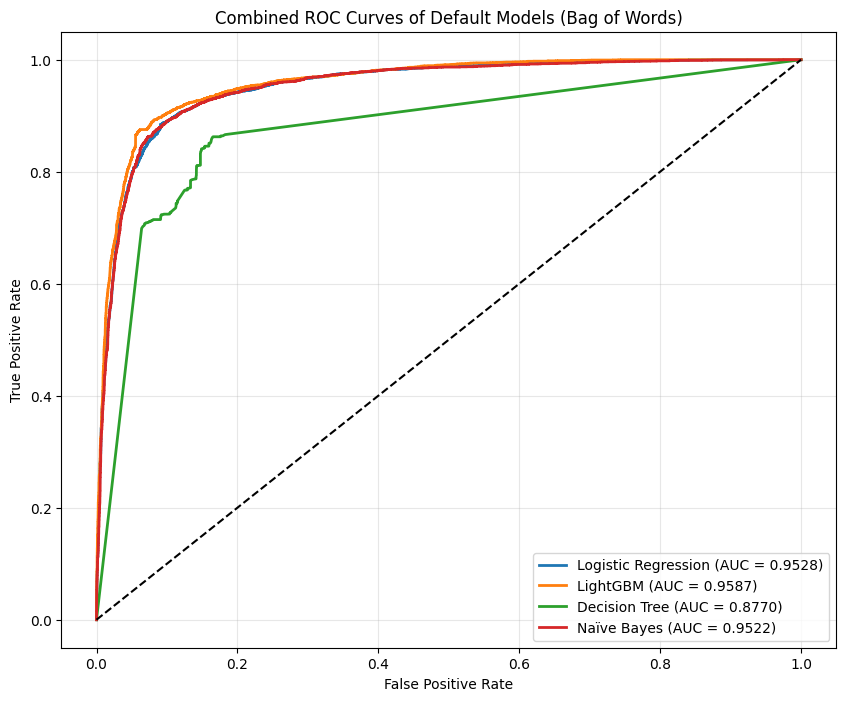

In [16]:
# I imported the required libraries.
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# I converted the test labels to binary format.
y_test_bin = label_binarize(
    y_test,
    classes=sorted(y_test.unique())
)

# I created a dictionary containing the models.
models = {
    "Logistic Regression": y_prob_bow,
    "LightGBM": y_prob_lightgbm_bow,
    "Decision Tree": y_prob_decision_tree_bow,
    "Naïve Bayes": y_prob_naive_bayes_bow
}

# I created the ROC curve figure.
plt.figure(figsize=(10,8))

# I plotted the micro-average ROC curve for each model.
for model_name, y_prob in models.items():

    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        y_prob.ravel()
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )

# I plotted the random classifier line.
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

# I customized the figure.
plt.title("Combined ROC Curves of Default Models (Bag of Words)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

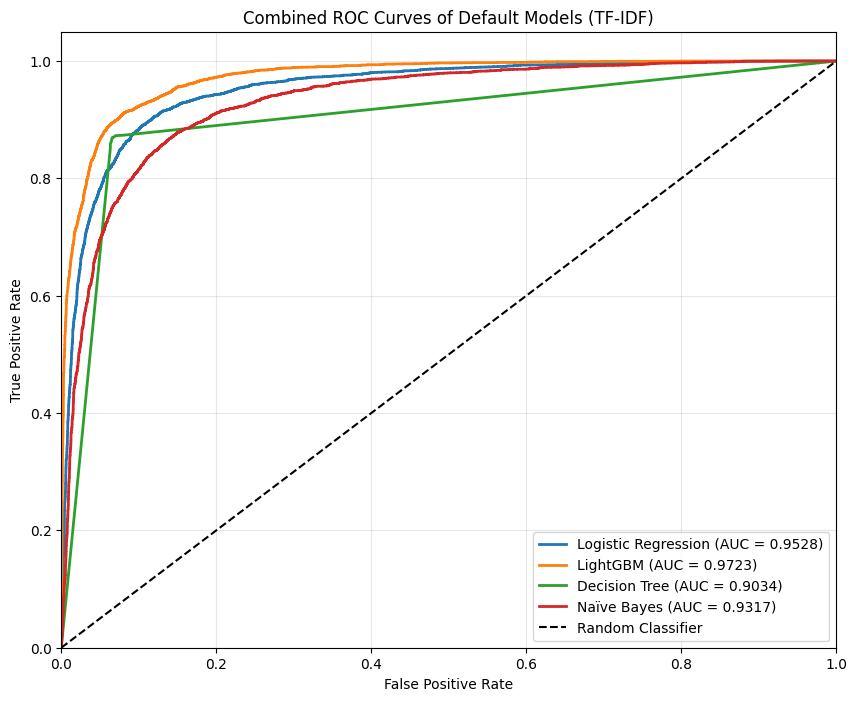

In [17]:
# I imported the required libraries.
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# I converted the test labels to binary format.
y_test_bin = label_binarize(
    y_test,
    classes=sorted(y_test.unique())
)

# I created a dictionary containing the predicted probabilities.
models = {
    "Logistic Regression": y_prob_tfidf,
    "LightGBM": y_prob_lightgbm_tfidf,
    "Decision Tree": y_prob_decision_tree_tfidf,
    "Naïve Bayes": y_prob_naive_bayes_tfidf
}

# I created the ROC curve figure.
plt.figure(figsize=(10, 8))

# I plotted the ROC curve for each model.
for model_name, y_prob in models.items():

    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        y_prob.ravel()
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )

# I plotted the random classifier line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Random Classifier"
)

# I customized the figure.
plt.title("Combined ROC Curves of Default Models (TF-IDF)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

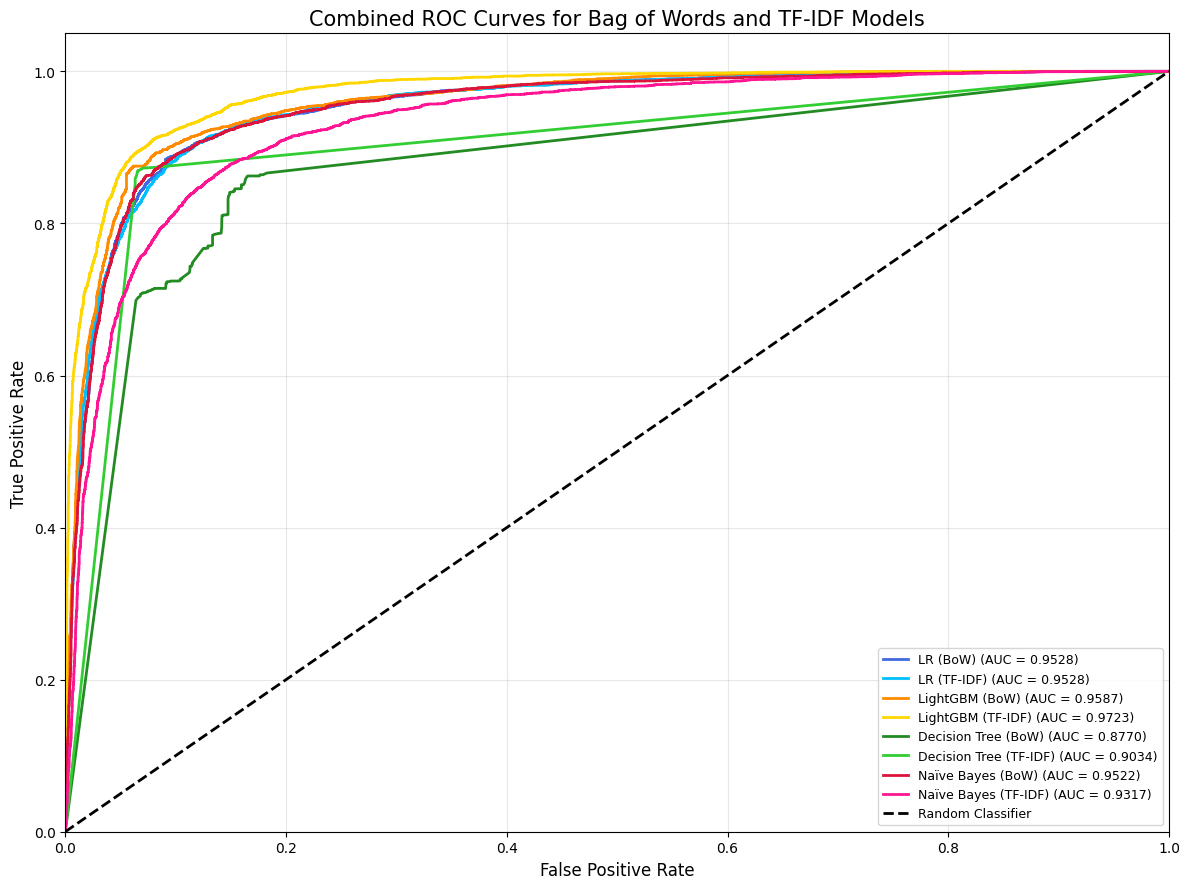

In [18]:
# I imported the required libraries.
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# I converted the test labels into binary format.
y_test_bin = label_binarize(
    y_test,
    classes=sorted(y_test.unique())
)

# I stored the predicted probabilities.
models = {
    "LR (BoW)": y_prob_bow,
    "LR (TF-IDF)": y_prob_tfidf,
    "LightGBM (BoW)": y_prob_lightgbm_bow,
    "LightGBM (TF-IDF)": y_prob_lightgbm_tfidf,
    "Decision Tree (BoW)": y_prob_decision_tree_bow,
    "Decision Tree (TF-IDF)": y_prob_decision_tree_tfidf,
    "Naïve Bayes (BoW)": y_prob_naive_bayes_bow,
    "Naïve Bayes (TF-IDF)": y_prob_naive_bayes_tfidf
}

# I created the figure.
plt.figure(figsize=(12,9))

colors = [
    "royalblue",
    "deepskyblue",
    "darkorange",
    "gold",
    "forestgreen",
    "limegreen",
    "crimson",
    "deeppink"
]

# I plotted the ROC curve for each model.
for (model_name, y_prob), color in zip(models.items(), colors):

    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        y_prob.ravel()
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )

# I plotted the random classifier.
plt.plot(
    [0,1],
    [0,1],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

# I customized the plot.
plt.title(
    "Combined ROC Curves for Bag of Words and TF-IDF Models",
    fontsize=15
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.xlim(0,1)
plt.ylim(0,1.05)

plt.grid(alpha=0.3)

plt.legend(
    loc="lower right",
    fontsize=9
)

plt.tight_layout()

plt.show()

# Next Step : Hyper Parameter Tuning 